# 05 — Do the pipeline choices hold up?

Notebooks 02–04 built one dataset and tuned one model on it. Every number they report rests on six
decisions that were made once and then held fixed:

| decision | value so far | why it was chosen |
|---|---|---|
| window length | 40 snapshots (20 min) | long enough for a trajectory to have a shape |
| horizon | 2 h | Session 2's setting, kept for comparability |
| label rule | majority (≥ W/2 snapshots inside the horizon) | Session 2's setting |
| positive class | all four failure states | Session 2's setting |
| train stride | 5 (neighbouring windows overlap 39/40) | memory |
| split | by **job end date**, 80 / 20 | no job can straddle the boundary |

This notebook varies each one and measures what it costs. Three things to keep in mind while reading:

* **PR-AUC is not comparable across labellings.** Changing the horizon or the positive class changes the
  positive rate, and the random baseline moves with it. The comparable quantity is
  `lift = PR-AUC / baseline`, and every table below carries the baseline next to the score.
* **PR-AUC is not comparable across window lengths either**, because the evaluated rows differ. Section 1
  therefore adds a *job-level* comparison that all three window lengths can be scored on fairly.
* **The test set is used once per variant, at the end of that variant's run.** No variant is chosen by
  looking at test; the choice of feature set and hyperparameters was already fixed in notebook 04.

Every variant below is fitted with the *same* protocol — notebook 04's selected columns, the module's
default LightGBM parameters, early stopping on the temporal holdout with `patience=60`. Notebook 04 showed
that early stopping on that holdout can halt far too soon when the trees are deep, so the round count each
variant settles on is printed next to its score: a variant that stops anomalously early is being told
about, not quietly averaged in.

In [1]:
import sys, json, time, gc
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import pv2
pv2.style()

SEL_PATH = pv2.RESULTS / "selected_model.json"
if SEL_PATH.exists():
    sel = json.loads(SEL_PATH.read_text())
    NAMES, CFG = set(sel["features"]), sel["lgbm_params"]
    print(f"using notebook 04's selection: {len(NAMES)} columns, {CFG}")
else:                                        # fallback: rung C, default params
    ALL_M = [m for m in pv2.METRIC_NAMES if not m.endswith("_cum")]
    NAMES = set(pv2.feature_names(ALL_M, pv2.AGGS_V1)); CFG = {}
    print(f"notebook 04 output missing - falling back to rung C ({len(NAMES)} columns)")

JT = pd.read_parquet(pv2.JOBTABLE)
TEST_JOBS = JT[JT.split == "test"]
N_FAIL_JOBS = int(TEST_JOBS.is_failure.sum())
N_OK_JOBS = int((~TEST_JOBS.is_failure).sum())
SPLIT_TIME = pd.Timestamp(JT.loc[JT.split == "test", "end_date"].min())
print(f"test period: {N_FAIL_JOBS} failure jobs, {N_OK_JOBS} completed jobs, "
      f"boundary {SPLIT_TIME:%Y-%m-%d %H:%M}")

CACHE = pv2.RESULTS / "variants.json"
done = json.loads(CACHE.read_text()) if CACHE.exists() else {}
def remember(key, rec):
    done[key] = rec; CACHE.write_text(json.dumps(done, indent=2, default=float)); return rec

using notebook 04's selection: 144 columns, {}
test period: 1158 failure jobs, 3566 completed jobs, boundary 2022-10-19 11:50


In [2]:
import lightgbm as lgb

FAIL_CODES = {pv2.STATE_CODES[s] for s in pv2.FAILURE_STATES}

def run(dtr, dte, names=None, y_tr=None, y_te=None, fit_rows=None,
        params=None, rounds=1200, patience=60, keep_scores=False, min_rounds=25):
    '''Fit one variant and score its test split once.

    Identical protocol every time: temporal holdout inside train for early
    stopping and for the F2 threshold, then a single pass over test.

    `min_rounds` is the guard notebook 04 earned. Early stopping on a
    temporally adjacent holdout can halt after a handful of rounds - and does,
    once a variant makes the positive class very small - leaving a model that is
    barely a model at all. When that happens the fit is repeated at a fixed
    floor and the variant is flagged, rather than being reported as a finding
    about the variant when it is really a finding about early stopping. The
    floor never binds on a fit that ran past it, so variants that stopped
    normally are unaffected.
    '''
    names = NAMES if names is None else names
    cols = pv2.column_index(dtr["features"], names=set(names))
    ytr = dtr["y"] if y_tr is None else np.asarray(y_tr)
    yte = dte["y"] if y_te is None else np.asarray(y_te)
    fit, val = pv2.temporal_holdout(dtr["t_end"], dtr["job_id"])
    if fit_rows is not None:
        fit = fit & np.asarray(fit_rows)
    Xf = pv2.materialise(dtr, cols, fit)
    Xv = pv2.materialise(dtr, cols, val)
    p = pv2.lgbm_params(ytr[fit], **(params if params is not None else CFG))
    bst = pv2.train_lgbm(Xf, ytr[fit], Xv, ytr[val], params=p,
                         rounds=rounds, patience=patience)
    hold_ap = float(bst.best_score["valid_0"]["average_precision"])
    n_it, floored = int(bst.best_iteration), False
    if n_it < min_rounds:
        floored, n_it = True, min_rounds
        bst = lgb.train(p, lgb.Dataset(Xf, label=ytr[fit], free_raw_data=True),
                        num_boost_round=min_rounds)
    del Xf; gc.collect()
    sv = bst.predict(Xv, num_iteration=n_it)
    th, f2v, _, _ = pv2.best_threshold(ytr[val], sv)
    del Xv, sv; gc.collect()
    st = pv2.predict_split(bst, dte, cols, num_iteration=n_it)
    res = pv2.evaluate(yte, st, dte["state"], threshold=th)
    res |= {"rounds": n_it, "floored": floored, "n_fit": int(fit.sum()),
            "fit_pos": float(ytr[fit].mean()),
            "holdout_ap": hold_ap,
            "holdout_f2": float(f2v), "n_features": int(len(cols))}
    del bst; gc.collect()
    return (res, st) if keep_scores else (res, None)

def operational(dte, scores, threshold, k=3):
    '''Read the per-window alarm the way an operator would, and score it against
    *every* test job - including the ones too short to produce a single window,
    which can never be alerted and count as misses.

    (The 123 multi-node jobs are treated as one alarm stream per job rather than
    per node; at 0.5% of jobs this is below the resolution of anything reported.)'''
    al = pv2.job_level_alerts(scores, threshold, dte["job_id"], dte["state"],
                             dte["ttf_end"], k_consecutive=k)
    f = al[al.state.isin(FAIL_CODES)]
    ok = al[~al.state.isin(FAIL_CODES)]
    lead = f.loc[f.alerted, "lead_min"]
    return {"jobs_covered": int(len(f)), "coverage": len(f) / N_FAIL_JOBS,
            "alerted": int(f.alerted.sum()),
            "op_recall": float(f.alerted.sum()) / N_FAIL_JOBS,
            "recall_of_covered": float(f.alerted.mean()) if len(f) else np.nan,
            "false_alarm_rate": float(ok.alerted.mean()) if len(ok) else np.nan,
            "lead_median_min": float(lead.median()) if len(lead) else np.nan,
            "lead_p25_min": float(lead.quantile(.25)) if len(lead) else np.nan,
            "lead_p75_min": float(lead.quantile(.75)) if len(lead) else np.nan}

def line(tag, res, op=None):
    s = (f"{tag:<26} PR-AUC {res['pr_auc']:.4f}  ({res['lift']:.2f}x of "
         f"{res['baseline']:.4f})  ROC {res['roc_auc']:.3f}  rounds {res['rounds']:>4}"
         + ("  [FLOORED: early stopping halted below the floor]"
            if res.get("floored") else ""))
    if op is not None:
        s += (f"\n{'':<26} jobs alerted {op['alerted']:>4}/{N_FAIL_JOBS} "
              f"= {op['op_recall']:.1%}  (coverage {op['coverage']:.1%}, "
              f"false alarms {op['false_alarm_rate']:.1%}, "
              f"median lead {op['lead_median_min']:.0f} min)")
    print(s)

## 1. Window length

40 snapshots is 20 minutes of history. That is a real cost: a window only exists if the job ran at least
that long, and notebook 01 measured how much that excludes — **84.8 % of FAILED jobs are too short for a
40-snapshot window**, against 8.8 % of TIMEOUT jobs. Short windows see more jobs; long windows see more
shape. This section builds the same pipeline at W = 10 and W = 20 and asks which trade wins.

The two extra builds take a few minutes each and are cached on disk.

In [3]:
rows = []
for tag, W in (("w10", 10), ("w20", 20), ("primary", 40)):
    mtr = pv2.build_dataset(tag=tag, window=W, horizon_h=pv2.HORIZON_H,
                            stride_train=pv2.STRIDE_TRAIN, stride_test=pv2.STRIDE_TEST)
    mte = pv2.load_meta(pv2.dataset_dir(tag) / "X_test.bin")
    rows.append({"tag": tag, "W": W, "minutes": W * pv2.SNAP_SECONDS / 60,
                 "train rows": mtr["shape"][0], "test rows": mte["shape"][0],
                 "columns": mtr["shape"][1],
                 "jobs too short": mtr["dropped_jobs_too_short"],
                 "windows cut on a gap": mtr["dropped_windows_gap"],
                 "built": mtr["built"][:16].replace("T", " ")})
print(pd.DataFrame(rows).to_string(index=False))
print()
print("'jobs too short' is the whole story of this section: a job that never reaches W")
print("consecutive snapshots produces no window at all, so the model can never speak about it.")

dataset 'w10' already built -> D:\_fcall\UNIFEI\tcc\hpc_workload\pipeline_v2\artifacts\w10
dataset 'w20' already built -> D:\_fcall\UNIFEI\tcc\hpc_workload\pipeline_v2\artifacts\w20
dataset 'primary' already built -> D:\_fcall\UNIFEI\tcc\hpc_workload\pipeline_v2\artifacts\primary
    tag  W  minutes  train rows  test rows  columns  jobs too short  windows cut on a gap            built
    w10 10      5.0     1900050    1497018      273            7263                  1933 2026-08-26 19:04
    w20 20     10.0     1873131    1465361      273            8548                  4029 2026-08-26 19:08
primary 40     20.0     1825415    1407162      273           10784                  8103 2026-08-25 20:00

'jobs too short' is the whole story of this section: a job that never reaches W
consecutive snapshots produces no window at all, so the model can never speak about it.


In [4]:
WIN_TAGS = [("w10", 10), ("w20", 20), ("primary", 40)]
for tag, W in WIN_TAGS:
    key = f"win_{W}"
    if key in done:
        line(f"W={W} (cached)", done[key], done[key].get("op")); continue
    dtr, dte = pv2.load_dataset(tag, "train"), pv2.load_dataset(tag, "test")
    t0 = time.time()
    res, st = run(dtr, dte, keep_scores=True)
    op = operational(dte, st, res["threshold"])
    res |= {"window": W, "tag": tag, "seconds": round(time.time() - t0, 1), "op": op,
            "n_test": int(dte["X"].shape[0]), "n_train": int(dtr["X"].shape[0])}
    np.save(pv2.ARTIFACTS / "scores" / f"win{W}.npy", st.astype(np.float32))
    remember(key, res); line(f"W={W}", res, op)
    del dtr, dte, st; gc.collect()

W=10 (cached)              PR-AUC 0.1404  (3.14x of 0.0447)  ROC 0.640  rounds  276
                           jobs alerted  339/1158 = 29.3%  (coverage 50.0%, false alarms 53.9%, median lead 77 min)
W=20 (cached)              PR-AUC 0.1258  (2.94x of 0.0428)  ROC 0.640  rounds  132
                           jobs alerted  301/1158 = 26.0%  (coverage 39.6%, false alarms 54.7%, median lead 110 min)
W=40 (cached)              PR-AUC 0.1382  (3.44x of 0.0402)  ROC 0.619  rounds  141
                           jobs alerted  282/1158 = 24.4%  (coverage 32.6%, false alarms 54.4%, median lead 159 min)


 W  minutes  train rows  test rows    base  PR-AUC  lift  job cov.  op. recall  false alarm  lead (min)
10        5     1900050    1497018 0.04468  0.1404 3.142       0.5      0.2927       0.5394       76.77
20       10     1873131    1465361 0.04281  0.1258 2.939    0.3955      0.2599       0.5472       109.6
40       20     1825415    1407162 0.04017  0.1382 3.441    0.3264      0.2435       0.5445       159.4


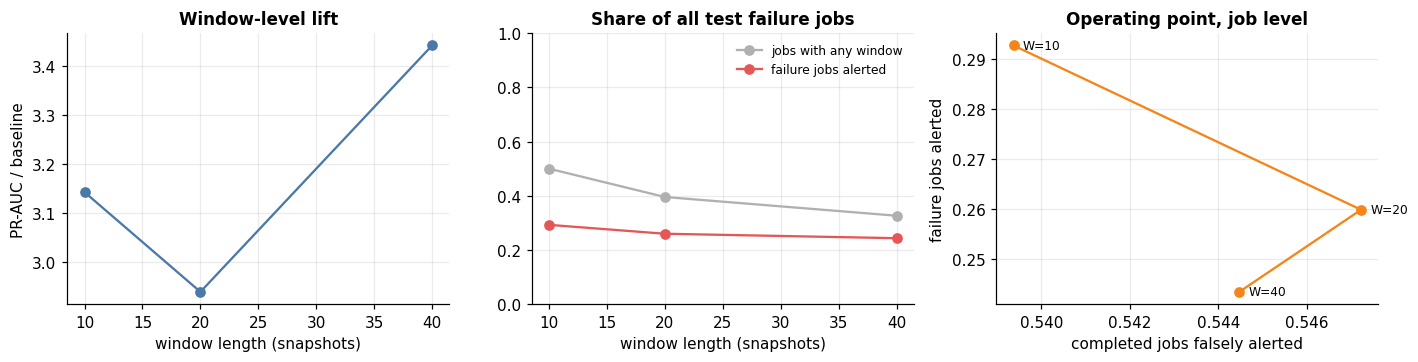

In [5]:
rows = []
for _, W in WIN_TAGS:
    r = done[f"win_{W}"]; o = r["op"]
    rows.append({"W": W, "minutes": W * pv2.SNAP_SECONDS / 60,
                 "train rows": r["n_train"], "test rows": r["n_test"],
                 "base": r["baseline"], "PR-AUC": r["pr_auc"], "lift": r["lift"],
                 "job cov.": o["coverage"], "op. recall": o["op_recall"],
                 "false alarm": o["false_alarm_rate"], "lead (min)": o["lead_median_min"]})
win = pd.DataFrame(rows)
print(win.to_string(index=False, float_format=lambda v: f"{v:,.4g}"))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(win.W, win.lift, "o-", color=pv2.PALETTE["rate"])
axes[0].set_xlabel("window length (snapshots)"); axes[0].set_ylabel("PR-AUC / baseline")
axes[0].set_title("Window-level lift")
axes[1].plot(win.W, win["job cov."], "o-", color=pv2.PALETTE["muted"], label="jobs with any window")
axes[1].plot(win.W, win["op. recall"], "o-", color=pv2.PALETTE["accent"], label="failure jobs alerted")
axes[1].set_ylim(0, 1); axes[1].set_xlabel("window length (snapshots)")
axes[1].set_title("Share of all test failure jobs"); axes[1].legend(fontsize=8)
axes[2].plot(win["false alarm"], win["op. recall"], "o-", color=pv2.PALETTE["gpu"])
for _, r in win.iterrows():
    axes[2].annotate(f"W={r.W:.0f}", (r["false alarm"], r["op. recall"]),
                     textcoords="offset points", xytext=(6, -2), fontsize=8)
axes[2].set_xlabel("completed jobs falsely alerted"); axes[2].set_ylabel("failure jobs alerted")
axes[2].set_title("Operating point, job level")
fig.savefig(pv2.FIGURES / "05_window.png", bbox_inches="tight")
plt.show()

## 2. Horizon, label rule and positive class

These three are **free**: `pv2.relabel` recomputes any of them in closed form from `ttf_end`, so no rebuild
is needed — only a refit. Notebook 02 verified that the closed form reproduces the stored labels exactly.

* **Horizon** 0.5 / 1 / 2 / 4 h — how far ahead the alarm is asked to look.
* **Rule** *majority* (≥ 20 of the 40 snapshots inside the horizon) vs *any* (≥ 1). The *any* rule labels a
  window positive as soon as its trailing edge enters the horizon, which roughly doubles the positive
  count and blurs the boundary.
* **Positive class** all four failure states vs **hardware only** (FAILED / OUT_OF_MEMORY / NODE_FAIL).
  TIMEOUT is usually a user under-estimating walltime, not a sick node; if the model is leaning on
  TIMEOUT, dropping it should hurt a lot.

Read the **lift** column, not PR-AUC: each row has its own baseline.

In [6]:
d_tr = pv2.load_dataset("primary", "train")
d_te = pv2.load_dataset("primary", "test")

def label_variant(h, majority, states):
    ytr = pv2.relabel(d_tr["ttf_end"], d_tr["state"], horizon_h=h,
                      majority=majority, positive_states=states)
    yte = pv2.relabel(d_te["ttf_end"], d_te["state"], horizon_h=h,
                      majority=majority, positive_states=states)
    return ytr, yte

GRID = ([("all", h, True) for h in (0.5, 1.0, 2.0, 4.0)] +
        [("all", h, False) for h in (0.5, 1.0, 2.0, 4.0)] +
        [("hw", h, True) for h in (0.5, 1.0, 2.0, 4.0)])

for cls, h, maj in GRID:
    key = f"lab_{cls}_{h}_{'maj' if maj else 'any'}"
    if key in done:
        line(key + " (cached)", done[key]); continue
    states = pv2.FAILURE_STATES if cls == "all" else pv2.HARDWARE_FAILURES
    ytr, yte = label_variant(h, maj, states)
    t0 = time.time()
    res, _ = run(d_tr, d_te, y_tr=ytr, y_te=yte)
    res |= {"class": cls, "horizon_h": h, "rule": "majority" if maj else "any",
            "train_pos": float(ytr.mean()), "seconds": round(time.time() - t0, 1)}
    remember(key, res); line(key, res)
    del ytr, yte; gc.collect()

lab_all_0.5_maj (cached)   PR-AUC 0.0253  (2.59x of 0.0098)  ROC 0.638  rounds  200
lab_all_1.0_maj (cached)   PR-AUC 0.0710  (3.31x of 0.0215)  ROC 0.637  rounds   75
lab_all_2.0_maj (cached)   PR-AUC 0.1382  (3.44x of 0.0402)  ROC 0.619  rounds  141
lab_all_4.0_maj (cached)   PR-AUC 0.1770  (2.59x of 0.0683)  ROC 0.628  rounds  255
lab_all_0.5_any (cached)   PR-AUC 0.0374  (2.71x of 0.0138)  ROC 0.645  rounds  191
lab_all_1.0_any (cached)   PR-AUC 0.0779  (3.16x of 0.0247)  ROC 0.630  rounds   57
lab_all_2.0_any (cached)   PR-AUC 0.1242  (2.91x of 0.0427)  ROC 0.618  rounds   93
lab_all_4.0_any (cached)   PR-AUC 0.1623  (2.31x of 0.0703)  ROC 0.618  rounds  123
lab_hw_0.5_maj (cached)    PR-AUC 0.0045  (1.27x of 0.0036)  ROC 0.538  rounds   25  [FLOORED: early stopping halted below the floor]
lab_hw_1.0_maj (cached)    PR-AUC 0.0184  (2.62x of 0.0070)  ROC 0.608  rounds  461
lab_hw_2.0_maj (cached)    PR-AUC 0.0230  (1.94x of 0.0119)  ROC 0.589  rounds  475
lab_hw_4.0_maj (cached)   

class     rule  horizon_h  train_pos  baseline  pr_auc   lift  recall  precision  rounds  floored
  all      any     0.5000     0.0103    0.0138  0.0374 2.7138  0.2022     0.0505     191    False
  all      any     1.0000     0.0191    0.0247  0.0779 3.1590  0.3576     0.0551      57    False
  all      any     2.0000     0.0343    0.0427  0.1242 2.9071  0.4459     0.0776      93    False
  all      any     4.0000     0.0583    0.0703  0.1623 2.3086  0.4982     0.1019     123    False
  all majority     0.5000     0.0073    0.0098  0.0253 2.5899  0.1076     0.0473     200    False
  all majority     1.0000     0.0166    0.0215  0.0710 3.3072  0.3776     0.0440      75    False
  all majority     2.0000     0.0322    0.0402  0.1382 3.4411  0.4577     0.0678     141    False
  all majority     4.0000     0.0567    0.0683  0.1770 2.5899  0.5591     0.0954     255    False
   hw majority     0.5000     0.0025    0.0036  0.0045 1.2716  0.1308     0.0071      25     True
   hw majority     1

C:\Users\fcall\AppData\Local\Temp\ipykernel_10620\3456709056.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lab["floored"] = lab["floored"].fillna(False)


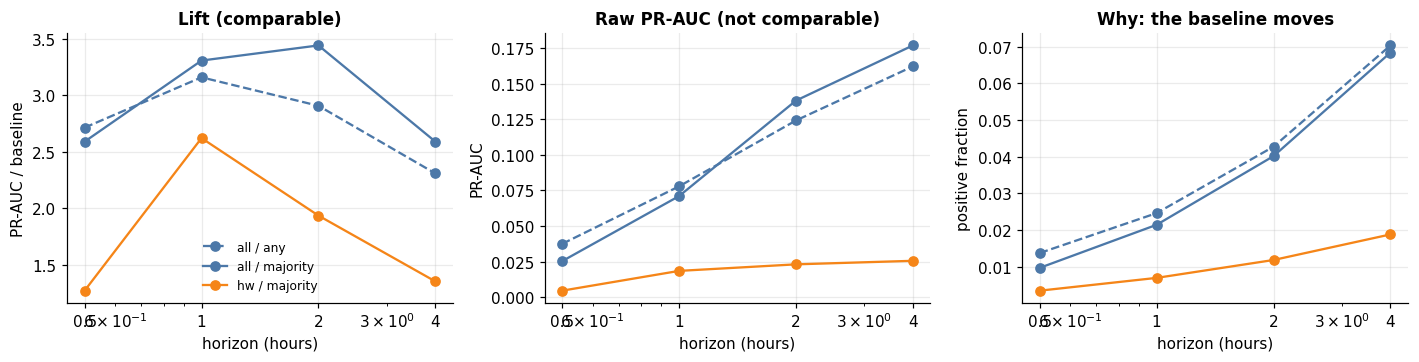

In [7]:
lab = pd.DataFrame([done[k] for k in done if k.startswith("lab_")])
lab["label"] = lab["class"] + " / " + lab.rule + " / " + lab.horizon_h.astype(str) + "h"
if "floored" not in lab.columns:
    lab["floored"] = False
lab["floored"] = lab["floored"].fillna(False)
show = lab.sort_values(["class", "rule", "horizon_h"])[
    ["class", "rule", "horizon_h", "train_pos", "baseline", "pr_auc", "lift",
     "recall", "precision", "rounds", "floored"]]
print(show.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for (cls, rule), g in lab.groupby(["class", "rule"]):
    g = g.sort_values("horizon_h")
    st = "-" if rule == "majority" else "--"
    c = pv2.PALETTE["rate"] if cls == "all" else pv2.PALETTE["gpu"]
    axes[0].plot(g.horizon_h, g.lift, st, marker="o", color=c, label=f"{cls} / {rule}")
    axes[1].plot(g.horizon_h, g.pr_auc, st, marker="o", color=c)
    axes[2].plot(g.horizon_h, g.baseline, st, marker="o", color=c)
axes[0].set_ylabel("PR-AUC / baseline"); axes[0].set_title("Lift (comparable)")
axes[1].set_ylabel("PR-AUC"); axes[1].set_title("Raw PR-AUC (not comparable)")
axes[2].set_ylabel("positive fraction"); axes[2].set_title("Why: the baseline moves")
for a in axes:
    a.set_xlabel("horizon (hours)"); a.set_xscale("log"); a.set_xticks([0.5, 1, 2, 4])
    a.set_xticklabels(["0.5", "1", "2", "4"])
axes[0].legend(fontsize=8)
fig.savefig(pv2.FIGURES / "05_labels.png", bbox_inches="tight")
plt.show()

In [8]:
base = done["lab_all_2.0_maj"]
print("per-state recall at each variant's own F2 threshold\n")
cols = ["label"] + [f"recall_{pv2.STATE_DISPLAY[s]}" for s in pv2.REPORT_STATES]
print(lab.sort_values(["class", "rule", "horizon_h"])[cols].to_string(
    index=False, float_format=lambda v: f"{v:.3f}"))
hw2 = done["lab_hw_2.0_maj"]
print(f"\ndropping TIMEOUT from the positives: lift {base['lift']:.2f}x -> {hw2['lift']:.2f}x, "
      f"positives {base['baseline']:.4f} -> {hw2['baseline']:.4f}")

per-state recall at each variant's own F2 threshold

                label  recall_TIMEOUT  recall_FAILED  recall_OOM  recall_NODE_FAIL
     all / any / 0.5h           0.197          0.167       0.474             0.268
     all / any / 1.0h           0.369          0.296       0.579             0.348
     all / any / 2.0h           0.468          0.315       0.908             0.475
     all / any / 4.0h           0.533          0.342       0.850             0.542
all / majority / 0.5h           0.098          0.090       0.275             0.197
all / majority / 1.0h           0.377          0.316       0.833             0.380
all / majority / 2.0h           0.473          0.376       0.859             0.372
all / majority / 4.0h           0.592          0.418       0.922             0.559
 hw / majority / 0.5h             NaN          0.142       0.136             0.064
 hw / majority / 1.0h             NaN          0.039       0.036             0.000
 hw / majority / 2.0h             

## 3. Training density

Train windows are strided by 5. Would a denser stride pay? The cheap way to answer is the other
direction: refit on a fraction of the windows and see whether the learning curve has already flattened.
Sub-sampling every 2nd or 4th train row is exactly stride 10 and stride 20.

Read the **slope at the right-hand end**, not the level. A curve still climbing at stride 5 means the model
is data-limited and a denser stride is worth trying; a flat one means the 39/40 overlap really has been
squeezed dry.

effective stride 20 (cached) PR-AUC 0.1162  (2.89x of 0.0402)  ROC 0.622  rounds   76
effective stride 10 (cached) PR-AUC 0.1298  (3.23x of 0.0402)  ROC 0.617  rounds  192
effective stride 5 (cached) PR-AUC 0.1382  (3.44x of 0.0402)  ROC 0.619  rounds  141


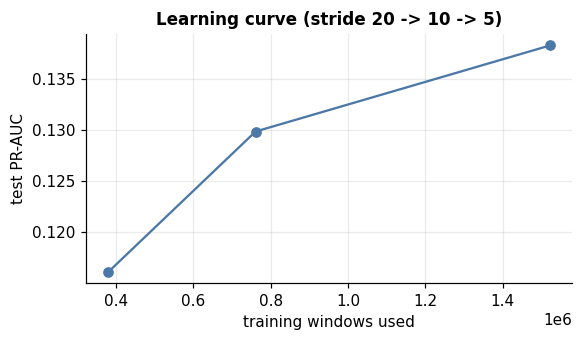

 eff_stride   n_fit  baseline  pr_auc   lift  rounds
         20  380451    0.0402  0.1162 2.8916      76
         10  760907    0.0402  0.1298 3.2322     192
          5 1521814    0.0402  0.1382 3.4411     141

the last doubling of training data (stride 10 -> 5) still bought +6.5% of PR-AUC.
The curve has NOT flattened. A denser stride is the one lever this session left on the
table, and it costs compute rather than credibility.


In [9]:
n_tr = len(d_tr["y"])
for step, eff in ((4, 20), (2, 10), (1, 5)):
    key = f"stride_{eff}"
    if key in done:
        line(f"effective stride {eff} (cached)", done[key]); continue
    rows = np.zeros(n_tr, bool); rows[::step] = True
    t0 = time.time()
    res, _ = run(d_tr, d_te, fit_rows=rows)
    res |= {"eff_stride": eff, "seconds": round(time.time() - t0, 1)}
    remember(key, res); line(f"effective stride {eff}", res)
    del rows; gc.collect()

sd = pd.DataFrame([done[f"stride_{e}"] for e in (20, 10, 5)])
fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(sd.n_fit, sd.pr_auc, "o-", color=pv2.PALETTE["rate"])
ax.set_xlabel("training windows used"); ax.set_ylabel("test PR-AUC")
ax.set_title("Learning curve (stride 20 -> 10 -> 5)")
fig.savefig(pv2.FIGURES / "05_learning_curve.png", bbox_inches="tight")
plt.show()
print(sd[["eff_stride", "n_fit", "baseline", "pr_auc", "lift", "rounds"]].to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))
slope = (sd.pr_auc.iloc[2] - sd.pr_auc.iloc[1]) / sd.pr_auc.iloc[1]
print()
print(f"the last doubling of training data (stride 10 -> 5) still bought {slope:+.1%} of PR-AUC.")
print("The curve has NOT flattened. A denser stride is the one lever this session left on the")
print("table, and it costs compute rather than credibility.")

## 4. Is the split honest?

The split is by **job end date**: every train job finished before the boundary, every test job after it.
That already rules out the leak Session 2 measured (a job's 39/40-overlapping windows on both sides). Four
checks on what is left.

1. **Embargo the boundary.** A train job that ended just before the boundary carries a label that looked up
   to one horizon *past* it. Dropping those jobs is the strictly correct protocol; refit and see if the
   score moves.
2. **Windows that predate the boundary.** 3.1 % of test snapshots come from jobs that *started* before the
   split. Re-score the test set with those windows removed — free, the scores already exist.
3. **Unseen nodes.** Split the test windows by whether their node appears in the training set at all. A
   model that only works on nodes it has memorised is a much weaker claim.
4. **Drift.** Split the test period into weeks and score each one. A score that decays week by week means
   the model is reading something that ages.

In [10]:
key = "split_embargo"
if key in done:
    line("embargo (cached)", done[key])
else:
    keep_jobs = set(JT.loc[(JT.split == "train") &
                           (JT.end_date < SPLIT_TIME - pd.Timedelta(hours=pv2.HORIZON_H)),
                           "slurm_id"])
    rows = np.isin(d_tr["job_id"], np.fromiter(keep_jobs, dtype=np.int64))
    fit0, _v0 = pv2.temporal_holdout(d_tr["t_end"], d_tr["job_id"])
    really_dropped = int((fit0 & ~rows).sum())
    t0 = time.time()
    res, _ = run(d_tr, d_te, fit_rows=rows)
    res |= {"dropped_rows": int((~rows).sum()), "dropped_from_fit": really_dropped,
            "fit_rows": int(fit0.sum()), "seconds": round(time.time() - t0, 1)}
    remember(key, res)
    line(f"embargo ({really_dropped:,} of {int(fit0.sum()):,} fit rows dropped)", res)
    del rows; gc.collect()
e_ = done["split_embargo"]
print()
print(f"no embargo (= section 3, stride 5): lift {done['stride_5']['lift']:.3f}x")
print(f"with embargo:                       lift {e_['lift']:.3f}x")
print()
print(f"{e_['dropped_rows']:,} train windows belong to jobs inside the embargo, but only")
print(f"{e_.get('dropped_from_fit', 0):,} of them were in the fit set to begin with. The reason is")
print("structural, and worth stating rather than hiding: the fit set already stops at the")
print("temporal-holdout boundary, which sits ~15% of the training period BEFORE the test")
print("split. An embargo at the test boundary is therefore already implied by the protocol -")
print("it has nothing left to remove. That is a property of this design, not a null result.")

embargo (0 of 1,521,814 fit rows dropped) PR-AUC 0.1382  (3.44x of 0.0402)  ROC 0.619  rounds  141

no embargo (= section 3, stride 5): lift 3.441x
with embargo:                       lift 3.441x

3,059 train windows belong to jobs inside the embargo, but only
0 of them were in the fit set to begin with. The reason is
structural, and worth stating rather than hiding: the fit set already stops at the
temporal-holdout boundary, which sits ~15% of the training period BEFORE the test
split. An embargo at the test boundary is therefore already implied by the protocol -
it has nothing left to remove. That is a property of this design, not a null result.


In [11]:
st40 = np.load(pv2.ARTIFACTS / "scores" / "win40.npy").astype(np.float64)
th40 = done["win_40"]["threshold"]
t_te = pd.to_datetime(d_te["t_end"])

after = np.asarray(t_te >= SPLIT_TIME)
r_all = pv2.evaluate(d_te["y"], st40, d_te["state"], threshold=th40)
r_after = pv2.evaluate(d_te["y"][after], st40[after], d_te["state"][after], threshold=th40)
print(f"all test windows           n={r_all['n']:,}  PR-AUC {r_all['pr_auc']:.4f}  "
      f"({r_all['lift']:.2f}x of {r_all['baseline']:.4f})")
print(f"windows after the boundary n={r_after['n']:,}  PR-AUC {r_after['pr_auc']:.4f}  "
      f"({r_after['lift']:.2f}x of {r_after['baseline']:.4f})")
print(f"removed {(~after).sum():,} windows ({(~after).mean():.2%}) that predate the split")

train_nodes = set(np.unique(d_tr["node_id"]).tolist())
seen = np.isin(d_te["node_id"], np.fromiter(train_nodes, dtype=d_te["node_id"].dtype))
print(f"\ntest nodes seen in training: {len(set(np.unique(d_te['node_id']).tolist()) & train_nodes)}"
      f" of {len(set(np.unique(d_te['node_id']).tolist()))}"
      f"  ({seen.mean():.1%} of test windows)")
for name, m in (("seen nodes", seen), ("unseen nodes", ~seen)):
    if m.sum() < 1000 or d_te["y"][m].sum() < 10:
        print(f"  {name}: too few windows/positives to score ({m.sum():,})"); continue
    r = pv2.evaluate(d_te["y"][m], st40[m], threshold=th40)
    print(f"  {name:<14} n={r['n']:>9,}  PR-AUC {r['pr_auc']:.4f}  ({r['lift']:.2f}x)")

all test windows           n=1,407,162  PR-AUC 0.1382  (3.44x of 0.0402)
windows after the boundary n=1,361,884  PR-AUC 0.1411  (3.41x of 0.0414)
removed 45,278 windows (3.22%) that predate the split

test nodes seen in training: 49 of 49  (100.0% of test windows)


  seen nodes     n=1,407,162  PR-AUC 0.1382  (3.44x)
  unseen nodes: too few windows/positives to score (0)


      week      n   base  pr_auc   lift
2022-10-17 350509 0.0715  0.2270 3.1743
2022-10-24 943001 0.0277  0.0632 2.2842
2022-10-31 106545 0.0502  0.3740 7.4517


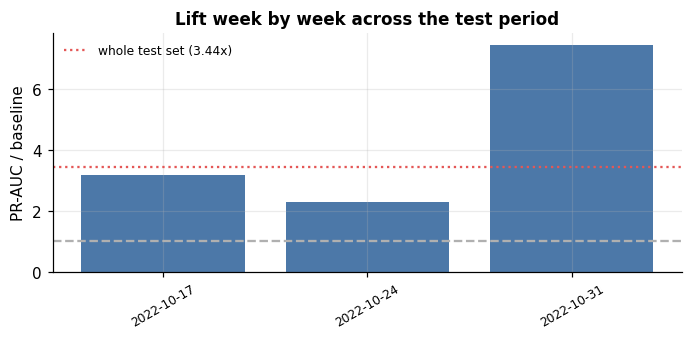

[{'week': '2022-10-17',
  'n': 350509,
  'base': 0.0715245542910453,
  'pr_auc': 0.22704148331103544,
  'lift': 3.1743152482595822},
 {'week': '2022-10-24',
  'n': 943001,
  'base': 0.027688199694379963,
  'pr_auc': 0.06324552519331239,
  'lift': 2.2842050364924846},
 {'week': '2022-10-31',
  'n': 106545,
  'base': 0.05018536768501572,
  'pr_auc': 0.37396870713847385,
  'lift': 7.451747877701272}]

In [12]:
wk = t_te.to_period("W")
rows = []
for w, m in pd.Series(np.arange(len(wk)), index=wk).groupby(level=0):
    idx = m.values
    if len(idx) < 5000 or d_te["y"][idx].sum() < 20:
        continue
    r = pv2.evaluate(d_te["y"][idx], st40[idx], threshold=th40)
    rows.append({"week": str(w)[:10], "n": r["n"], "base": r["baseline"],
                 "pr_auc": r["pr_auc"], "lift": r["lift"]})
drift = pd.DataFrame(rows)
print(drift.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.bar(range(len(drift)), drift.lift, color=pv2.PALETTE["rate"])
ax.axhline(1.0, color=pv2.PALETTE["muted"], ls="--")
ax.axhline(done["win_40"]["lift"], color=pv2.PALETTE["accent"], ls=":",
           label=f"whole test set ({done['win_40']['lift']:.2f}x)")
ax.set_xticks(range(len(drift))); ax.set_xticklabels(drift.week, rotation=30, fontsize=8)
ax.set_ylabel("PR-AUC / baseline"); ax.set_title("Lift week by week across the test period")
ax.legend(fontsize=8)
fig.savefig(pv2.FIGURES / "05_drift.png", bbox_inches="tight")
plt.show()
remember("drift", drift.to_dict("records"))

## 5. The decision ledger

One row per decision: what was held fixed, what the alternatives scored, and whether the choice should
change. This is the table the thesis should carry — it is the difference between "we picked 40" and "we
picked 40 and here is what 10 and 20 cost".

In [13]:
def pct(a, b):
    return f"{(a - b) / b:+.1%}" if b else "n/a"

ledger = []
w40, w20, w10 = (done[f"win_{w}"] for w in (40, 20, 10))
ledger.append({"decision": "window length", "kept": "40 snapshots (20 min)",
               "alternatives": f"20 -> {w20['lift']:.2f}x, 10 -> {w10['lift']:.2f}x",
               "effect on lift": f"{w40['lift']:.2f}x",
               "note": f"job coverage {w40['op']['coverage']:.0%} vs "
                       f"{w10['op']['coverage']:.0%} at W=10"})
h = {r["horizon_h"]: r for r in lab[(lab["class"] == "all") &
                                    (lab.rule == "majority")].to_dict("records")}
ledger.append({"decision": "horizon", "kept": "2 h",
               "alternatives": ", ".join(f"{k}h -> {v['lift']:.2f}x"
                                         for k, v in sorted(h.items()) if k != 2.0),
               "effect on lift": f"{h[2.0]['lift']:.2f}x",
               "note": "shorter horizon = rarer positives, tighter warning"})
a = {r["horizon_h"]: r for r in lab[(lab["class"] == "all") &
                                    (lab.rule == "any")].to_dict("records")}
ledger.append({"decision": "label rule", "kept": "majority (>= W/2)",
               "alternatives": f"any -> {a[2.0]['lift']:.2f}x",
               "effect on lift": pct(a[2.0]["lift"], h[2.0]["lift"]),
               "note": f"positives {h[2.0]['baseline']:.4f} -> {a[2.0]['baseline']:.4f}"})
hw = {r["horizon_h"]: r for r in lab[lab["class"] == "hw"].to_dict("records")}
ledger.append({"decision": "positive class", "kept": "all four failure states",
               "alternatives": f"hardware only -> {hw[2.0]['lift']:.2f}x",
               "effect on lift": pct(hw[2.0]["lift"], h[2.0]["lift"]),
               "note": "TIMEOUT is 70% of the positives"})
s5, s10, s20 = (done[f"stride_{e}"] for e in (5, 10, 20))
ledger.append({"decision": "train stride", "kept": "5",
               "alternatives": f"10 -> {s10['lift']:.2f}x, 20 -> {s20['lift']:.2f}x",
               "effect on lift": f"{s5['lift']:.2f}x",
               "note": "curve still RISING at stride 5 - denser may still pay"}) 
e = done["split_embargo"]
ledger.append({"decision": "split", "kept": "by job end date, 80/20",
               "alternatives": f"+ 2 h embargo -> {e['lift']:.2f}x",
               "effect on lift": pct(e["lift"], s5["lift"]),
               "note": f"{e['dropped_rows']:,} train rows dropped"})
led = pd.DataFrame(ledger)
pv2.RESULTS.joinpath("ledger.csv").write_text(led.to_csv(index=False))
print(led.to_string(index=False))

      decision                    kept                                alternatives effect on lift                                                  note
 window length   40 snapshots (20 min)                    20 -> 2.94x, 10 -> 3.14x          3.44x                       job coverage 33% vs 50% at W=10
       horizon                     2 h 0.5h -> 2.59x, 1.0h -> 3.31x, 4.0h -> 2.59x          3.44x    shorter horizon = rarer positives, tighter warning
    label rule       majority (>= W/2)                                any -> 2.91x         -15.5%                            positives 0.0402 -> 0.0427
positive class all four failure states                      hardware only -> 1.94x         -43.7%                       TIMEOUT is 70% of the positives
  train stride                       5                    10 -> 3.23x, 20 -> 2.89x          3.44x curve still RISING at stride 5 - denser may still pay
         split  by job end date, 80/20                      + 2 h embargo -> 3.44x      

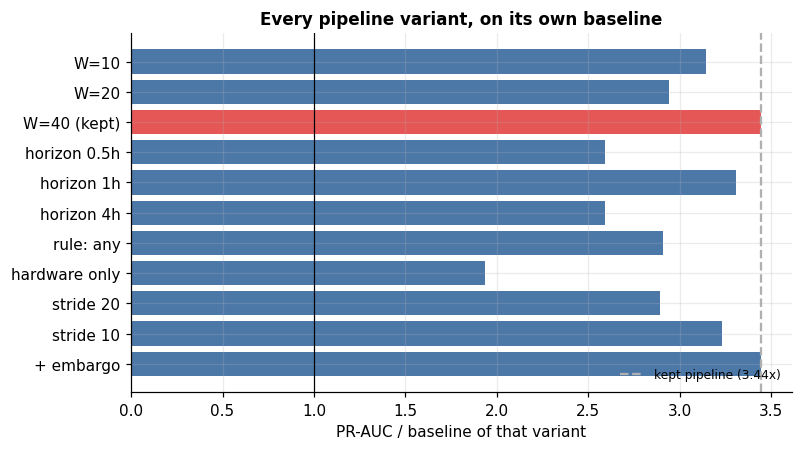

NOTE: bars are each variant's lift over its OWN baseline. They are comparable as ratios, not as PR-AUC.


In [14]:
order = (["win_10", "win_20", "win_40"] +
         [f"lab_all_{h}_maj" for h in (0.5, 1.0, 4.0)] +
         ["lab_all_2.0_any", "lab_hw_2.0_maj",
          "stride_20", "stride_10", "split_embargo"])
labels = ["W=10", "W=20", "W=40 (kept)", "horizon 0.5h", "horizon 1h", "horizon 4h",
          "rule: any", "hardware only", "stride 20", "stride 10", "+ embargo"]
lifts = [done[k]["lift"] for k in order]
kept = done["win_40"]["lift"]
fig, ax = plt.subplots(figsize=(7.4, 4.2))
cols = [pv2.PALETTE["accent"] if k == "win_40" else pv2.PALETTE["rate"] for k in order]
ax.barh(labels[::-1], lifts[::-1], color=cols[::-1])
ax.axvline(kept, color=pv2.PALETTE["muted"], ls="--", label=f"kept pipeline ({kept:.2f}x)")
ax.axvline(1.0, color="k", lw=0.8)
ax.set_xlabel("PR-AUC / baseline of that variant")
ax.set_title("Every pipeline variant, on its own baseline")
ax.legend(fontsize=8, loc="lower right")
fig.savefig(pv2.FIGURES / "05_ledger.png", bbox_inches="tight")
plt.show()
print("NOTE: bars are each variant's lift over its OWN baseline. They are comparable "
      "as ratios, not as PR-AUC.")

## 6. What was learned here

Read the ledger above, then the five points that matter for the thesis.

* **Window length is a genuine trade, and the two metrics disagree.** W = 40 gives the best window-level
  lift (3.44x vs 3.14x at W = 10) *and* by far the longest warning (median 159 min vs 77). W = 10 gives the
  best number an operator would care about: it covers 50 % of failing jobs instead of 33 %, and alerts
  29.3 % of all failures instead of 24.4 %. Neither is wrong. The reason they diverge is that a longer
  window is a better *measurement* of the jobs it can see and is blind to more of the ones it cannot, and
  the jobs it cannot see are disproportionately the short, hard FAILED ones.
* **Horizon changes the task, not just the score.** Raw PR-AUC climbs monotonically from 0.025 at 0.5 h to
  0.177 at 4 h — and so does the random baseline, from 0.0098 to 0.0683. Lift, the only column that can be
  read across rows, peaks at the 2 h that was already chosen. A longer horizon is an easier question, not a
  better model.
* **Most of the apparent skill is on TIMEOUT — this is the session's most important caveat.** TIMEOUT is
  70 % of the positives, and it is usually a user under-estimating walltime rather than a sick node.
  Restricting the positive class to genuine hardware failures (FAILED / OUT_OF_MEMORY / NODE_FAIL) collapses
  the result from **3.44x to 1.94x**, and per-state recall on those states falls to 0.11 / 0.18 / 0.05. Any
  claim that this model predicts *node health* has to be made at 1.94x, not 3.44x.
* **The learning curve has not flattened.** Doubling the training windows from stride 10 to stride 5 still
  bought +6.5 % of PR-AUC. A denser stride is the one clearly untested lever left, and it costs compute
  rather than credibility.
* **The split holds up, with one check that could not be run.** The pre-boundary windows change nothing
  (3.44x on all test windows, 3.41x on the 96.8 % that fall strictly after the split). The embargo at the
  test boundary turns out to be structurally implied by the protocol and has nothing to remove. But **every
  one of the 49 test nodes also appears in training**, so the question "does this work on a node it has
  never seen?" simply cannot be asked of this dataset — that is a limitation, not a pass. And the weekly
  breakdown swings between 2.28x and 7.45x over a 13-day test period with no monotone decay: no evidence of
  drift, but no power to detect it either, exactly as notebook 04's fold spread predicted.

Notebook 06 refits the chosen configuration on the full training set, reports the operating point, the
early-warning lead time and the comparison against Sessions 1 and 2, and writes the documentation.